In [78]:
import numpy as np
import cma
import networkx as nx
import matplotlib.pyplot as plt

from networkx import erdos_renyi_graph, grid_graph
from pycellga.mutation.byte_mutation_random import ByteMutationRandom
from pycellga.recombination.byte_one_point_crossover import ByteOnePointCrossover
from pycellga.selection.tournament_selection import TournamentSelection

from pycellga.GraphProblem import GraphRastriginProblem
from pycellga.optimizer import graph_cga
from typing import Tuple

In [79]:

BOUNDARIES = 5

### set up the problem
for CGA we need a graph, for CMA only the function implementation will be needed

In [80]:
def set_up_problem(n_rows, n_cols, dims, offset) -> GraphRastriginProblem:
    torus_graph = grid_graph(dim=(n_rows, n_cols), periodic=True)
    torus_graph_nodes_flattened = {node: i for i, node in enumerate(torus_graph.nodes)}
    empty_graph = nx.Graph()
    for edge in torus_graph.edges:
        empty_graph.add_edge(torus_graph_nodes_flattened[edge[0]], torus_graph_nodes_flattened[edge[1]])
    torus_graph = empty_graph

    #setting up random offset to see 
    return GraphRastriginProblem(n_var=dims, graph=torus_graph, offset=offset)

## CGA

In [81]:
def run_cga(dims, n_generations, n_rows, n_cols, problem):
    result = graph_cga(
        n_rows=n_rows,
        n_cols=n_cols,
        n_gen=n_generations,
        ch_size=dims,
        p_crossover=0.9,
        p_mutation=0.2,
        problem=problem,
        selection=TournamentSelection,
        recombination=ByteOnePointCrossover,
        mutation=ByteMutationRandom,
        seed_par=100,
    )
    return (result.chromosome, result.fitness_value)

## CMA-ES

In [82]:
def run_cma(problem, dims, max_evals):
    x0 = np.random.random(dims)    
    sigma = 0.5

    es = cma.CMAEvolutionStrategy(x0, 
        sigma, 
        {
        'maxfeval': max_evals,
        'verb_disp': 0,
        'bounds': [[-5, -5], [5, 5]]  
        }
        )

    while not es.stop():
        solutions = es.ask()                  
        function_value = [problem.f(x) for x in solutions]  
        es.tell(solutions, function_value) 
    return (es.result.xbest, es.result.fbest)                          


## Comparison


In [112]:
from sklearn.decomposition import PCA
import seaborn as sns



def single_test(offset, n_rows, n_cols, n_generations, dims, repetitions=10):
    
    cma_results = []
    cga_results = []
    
    problem = set_up_problem(n_rows, n_cols, dims, offset)
    i = 0
    while i < repetitions:
        try:
            cga_result =run_cga(dims, n_generations, n_rows, n_cols, problem)
            cma_result = run_cma(problem, dims, n_generations * n_rows * n_cols)
            
        except ValueError as e: # sometimes it doesn't find element in list, just repeat
            print(e)
            continue
        
        cga_results.append(cga_result)
        cma_results.append(cma_result)
        i += 1

    return (cga_results, cma_results)
    
def visualize_results(cga_results, cma_results, parameters):
    values = np.array(list(map(lambda x: x[1], cga_results + cma_results)))
    sizes = - values
    
    sizes -= sizes.min()
    sizes = sizes/sizes.max() * 40 + 5


    i = len(cma_results)
    pca = PCA(n_components=2)
    transformed = pca.fit_transform(np.array(list(map(lambda x: x[0], cga_results + cma_results))))
    plt.scatter(x=transformed[:i, 0], y=transformed[:i, 1], c='red', label='cga', s=sizes[:i], alpha=0.7)
    plt.scatter(x=transformed[i:, 0], y=transformed[i:, 1], c='blue', label='cma', s=sizes[i:], alpha=0.7)

    minimum = pca.transform(parameters['offset'] * np.ones((1, parameters['dims'])))
    plt.scatter(x=minimum[0, 0], y=minimum[0, 1], c='green', s=40, label='global_minumum', marker='x')
    plt.title(f'dims: {parameters['dims']}   ROWSxCOLS: {parameters['n_rows']} x {parameters['n_cols']}')

    # for point, result in zip(transformed, cga_results + cma_results):
    #     print(point, result[1])
    #     plt.annotate(f"{result[1]:.0f}", point, point - np.array([0.2, 0.3]))

    plt.legend()
    plt.show()
    

In [142]:
def test_parameters(parameter_dicts, repetitions=30, visualize_steps=True):
    
    for parameters in parameter_dicts:

        minimum = np.ones(parameters['dims']) * parameters['offset']
        minimum_val = - 100 * parameters['dims'] ** 2
        cga_results, cma_results = single_test(**parameters, repetitions=repetitions)
        if visualize_steps:
            visualize_results(cga_results, cma_results, parameters)

        distances_cga = list(map(lambda x:np.linalg.norm(x[0] - minimum), cga_results))
        distances_cma = list(map(lambda x:np.linalg.norm(x[0] - minimum), cma_results))
        errors_cga = list(map(lambda x:(np.array(x[1]) - minimum_val), cga_results))
        errors_cma = list(map(lambda x:(np.array(x[1]) - minimum_val), cma_results))


        fig, ax = plt.subplots(1, 2)
        fig.set_size_inches(10, 5)
        ax[0].hist(distances_cga, label='cga', color='red', alpha=0.7, rwidth=0.5)
        ax[0].hist(distances_cma, label='cma', color='blue', alpha=0.7, rwidth=0.5)
        # ax[0].legend()

        ax[1].hist(errors_cga, label='cga', color='red', alpha=0.7, rwidth=200)
        ax[1].hist(errors_cma, label='cma', color='blue', alpha=0.7, rwidth=200)
        ax[1].legend()

        plt.show()



        
        

In [143]:
parameters = {
    'dims' : 10,
    'n_generations' : 100,
    'n_rows' : 10,
    'n_cols' : 10,
    'offset' : np.random.rand() * np.random.randint(1, BOUNDARIES) * (-1) ** np.random.randint(0, 2)
}

parameters2 = {
    'dims' : 20,
    'n_generations' : 100,
    'n_rows' : 10,
    'n_cols' : 10,
    'offset' : np.random.rand() * np.random.randint(1, BOUNDARIES) * (-1) ** np.random.randint(0, 2)
}

parameters3 = {
    'dims' : 10,
    'n_generations' : 100,
    'n_rows' : 20,
    'n_cols' : 20,
    'offset' : np.random.rand() * np.random.randint(1, BOUNDARIES) * (-1) ** np.random.randint(0, 2)
}

parameters4 = {
    'dims' : 4,
    'n_generations' : 100,
    'n_rows' : 5,
    'n_cols' : 5,
    'offset' : np.random.rand() * np.random.randint(1, BOUNDARIES) * (-1) ** np.random.randint(0, 2)
}

C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in square
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in multiply
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in cos
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:28: RuntimeWarning: overflow encountered in scalar multiply
  10
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in subtract
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
c:\Install\anaconda\envs\IO_env\Lib

<pycellga.individual.Individual object at 0x0000022AE0304E90> is not in list
<pycellga.individual.Individual object at 0x0000022AE03655E0> is not in list
<pycellga.individual.Individual object at 0x0000022AE03B7230> is not in list


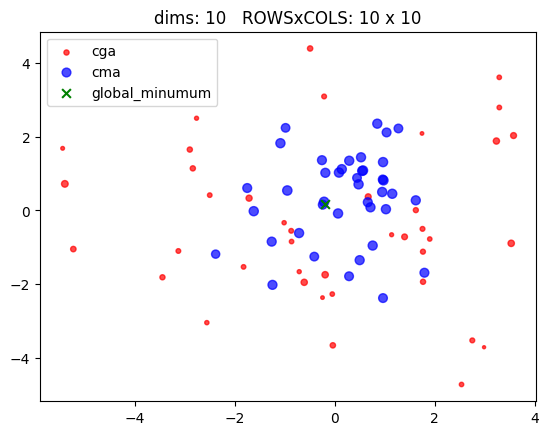

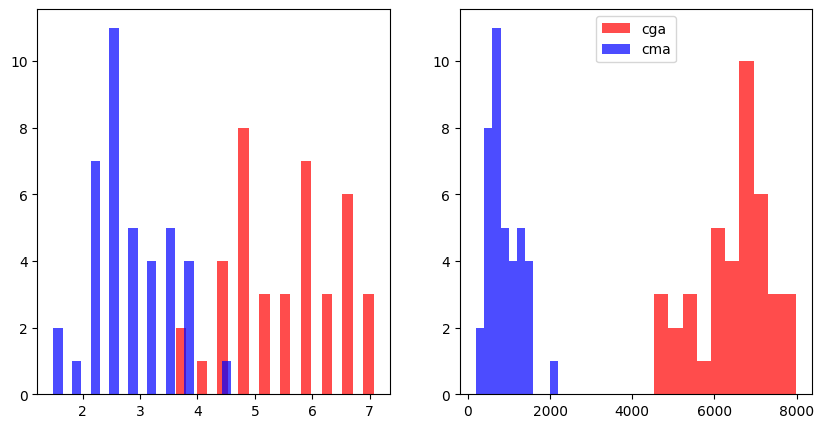

C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in square
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in multiply
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in cos
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in subtract
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:28: RuntimeWarning: overflow encountered in scalar multiply
  10
c:\Install\anaconda\envs\IO_env\Lib

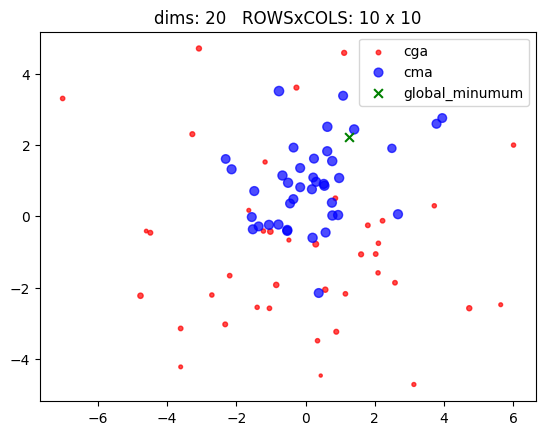

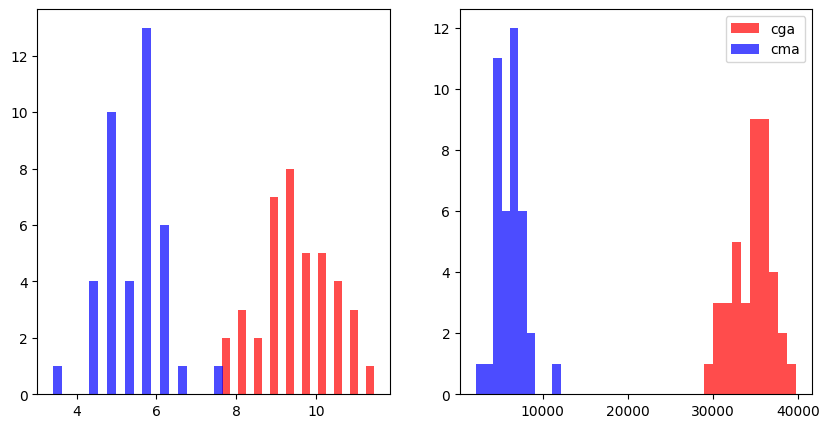

C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in square
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in subtract
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:28: RuntimeWarning: overflow encountered in scalar multiply
  10
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in multiply
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in cos
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))


<pycellga.individual.Individual object at 0x0000022AE05B3170> is not in list
<pycellga.individual.Individual object at 0x0000022AE08124E0> is not in list
<pycellga.individual.Individual object at 0x0000022AE07BDCA0> is not in list
<pycellga.individual.Individual object at 0x0000022AE090EDB0> is not in list
<pycellga.individual.Individual object at 0x0000022AE090E330> is not in list
<pycellga.individual.Individual object at 0x0000022AE090F980> is not in list
<pycellga.individual.Individual object at 0x0000022AE0813050> is not in list


c:\Install\anaconda\envs\IO_env\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


<pycellga.individual.Individual object at 0x0000022AE090EE70> is not in list
<pycellga.individual.Individual object at 0x0000022AE0813260> is not in list
<pycellga.individual.Individual object at 0x0000022AE090D190> is not in list
<pycellga.individual.Individual object at 0x0000022AE090C2F0> is not in list
<pycellga.individual.Individual object at 0x0000022AE08F1A60> is not in list
<pycellga.individual.Individual object at 0x0000022AE090F560> is not in list
<pycellga.individual.Individual object at 0x0000022AE08F1A60> is not in list
<pycellga.individual.Individual object at 0x0000022AE090E960> is not in list
<pycellga.individual.Individual object at 0x0000022AE090CB90> is not in list
<pycellga.individual.Individual object at 0x0000022AE090F7A0> is not in list
<pycellga.individual.Individual object at 0x0000022AE090D7F0> is not in list
<pycellga.individual.Individual object at 0x0000022AE08F1130> is not in list
<pycellga.individual.Individual object at 0x0000022AE08129C0> is not in list

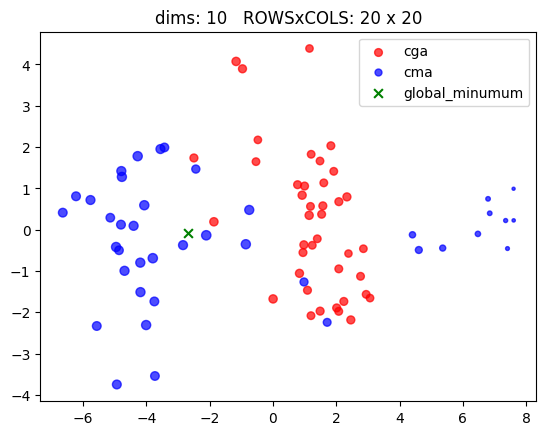

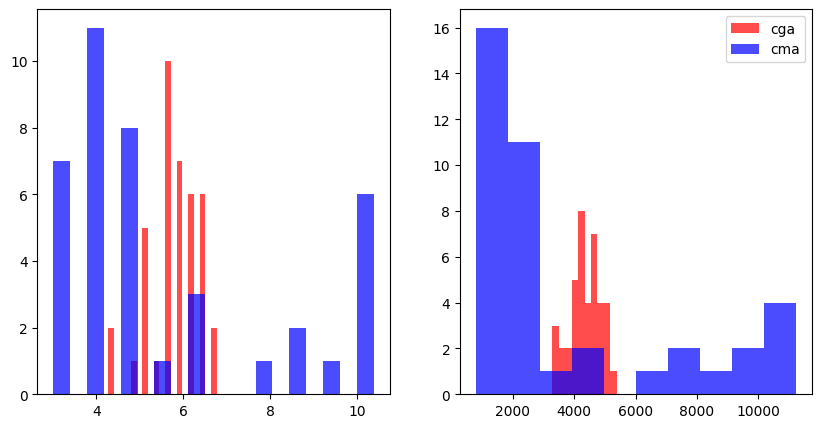

C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in square
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in subtract
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: overflow encountered in multiply
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:31: RuntimeWarning: invalid value encountered in cos
  (x - self.offset) ** 2 - 10 * np.cos(2 * np.pi * (x - self.offset))
C:\Users\Przemek\Documents\Studia\8_semestr\IO\pycellga\pycellga\GraphProblem.py:28: RuntimeWarning: overflow encountered in scalar multiply
  10


<pycellga.individual.Individual object at 0x0000022AE0BA6AE0> is not in list
<pycellga.individual.Individual object at 0x0000022AE099A870> is not in list
<pycellga.individual.Individual object at 0x0000022AE0999D00> is not in list
<pycellga.individual.Individual object at 0x0000022AE0998BF0> is not in list
<pycellga.individual.Individual object at 0x0000022AE09997F0> is not in list
<pycellga.individual.Individual object at 0x0000022AE0998860> is not in list
<pycellga.individual.Individual object at 0x0000022AE0998650> is not in list
<pycellga.individual.Individual object at 0x0000022AE0998710> is not in list
<pycellga.individual.Individual object at 0x0000022AE0A0C170> is not in list
<pycellga.individual.Individual object at 0x0000022AE0953B60> is not in list
<pycellga.individual.Individual object at 0x0000022AE0952D80> is not in list
<pycellga.individual.Individual object at 0x0000022AE0998920> is not in list
<pycellga.individual.Individual object at 0x0000022AE0BA41D0> is not in list

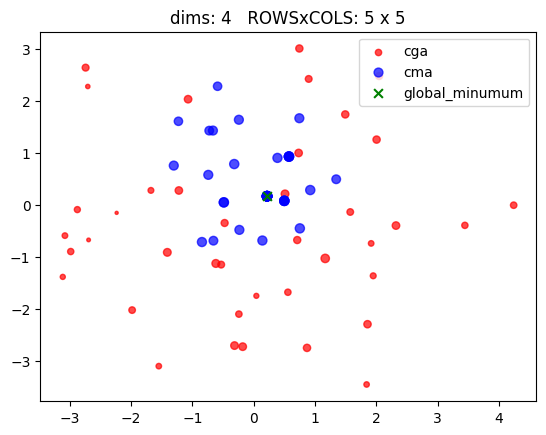

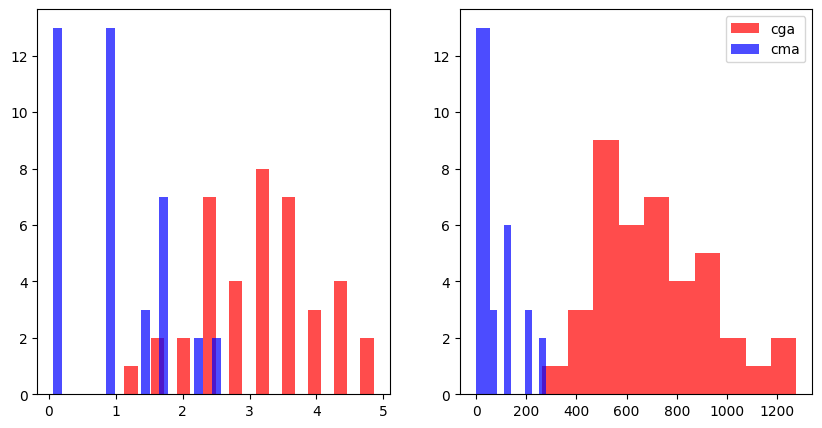

In [146]:
test_parameters([parameters, parameters2, parameters3, parameters4], repetitions=40)